Завдання 2


1. Використовуючи датасет diabetes_data.csv створити модель на базі глибокої нейронної мережі для класифікування даних.
2. Розбити датасет на 3 підвибірки: тренувальний (70%), валідаційний (20%), тестовий (10%), використовучі власну функцію, або функції які реалізовані в pandas чи sklearn.
3. Дослідити як впливає скейлінг і нормалізація даних на результат моделі https://scikit-learn.org/stable/modules/preprocessing.html
4. Імплементувати модель в Keras за допомогою Sequentinal(). Обгрунтувати обрання кількості нейронів та шарів. Провести
дослідження, як буде мінятися точність мережі при різних гіперпараметрах.
5. В якості оптимізатора застосувати декілька алгоритмів навчання (https://keras.io/api/optimizers/ ):
    - SGD
    - RMSprop
    - Adam
    - Adadelta
    - Adagrad
    - Adamax
    - Nadam
6. Використати різні активаційні функції і виявити вплив виду функції та точність моделі.
7. Побудувати графіки навчання по кожному оптимізатору і порівняти швидкість збіжності алгоритмів.
8. Провести тестування мережі. Визначити чи не було перенавчання мережі.

All the imports in one place

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, auc, recall_score, precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
from tensorflow.python.keras.utils.np_utils import to_categorical

Load the data for the regression

In [2]:
#read in data using pandas
train_df = pd.read_csv('../data/diabetes_data.csv')
#check data has been read in properly
train_df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [31]:
train_df.shape

(768, 8)

In [3]:
train_df.describe(include='all')

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
train_df.isna().sum()

pregnancies    0
glucose        0
diastolic      0
triceps        0
insulin        0
bmi            0
dpf            0
age            0
diabetes       0
dtype: int64

Split data into training features and feature to predict

In [3]:
y = train_df['diabetes']
train_df = train_df.drop('diabetes', axis=1)
X = train_df

In [4]:
y = to_categorical(y)
y

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [1., 0.]], shape=(768, 2), dtype=float32)

In [5]:
X.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


Split the data into training, validation and test datasets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
  X,y, random_state=42, test_size=0.3, shuffle=True)

In [7]:
X_test, X_val, y_test, y_val = train_test_split(
  X_test,y_test, random_state=42, test_size=0.33, shuffle=True)

Do data scaling for better results

In [8]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)


y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)
y_val = y_scaler.transform(y_val)

In [11]:
X_train

array([[-0.8362943 , -0.80005088, -0.53576428, ..., -1.06015343,
        -0.61421636, -0.94861028],
       [ 0.39072767, -0.49054341,  0.12804365, ...,  0.64646721,
        -0.90973787, -0.43466673],
       [-1.14304979,  0.43797901, -0.09322566, ...,  1.35537117,
        -0.30699103, -0.77729576],
       ...,
       [ 1.92450513, -0.6143464 ,  0.90248622, ...,  1.78859026,
         1.94892066,  0.42190587],
       [-1.14304979,  0.62368349, -3.8548039 , ...,  1.36849903,
        -0.77514391, -0.34900947],
       [-1.14304979,  0.12847154,  1.45565949, ..., -1.24394334,
        -0.60836445, -1.03426754]], shape=(537, 8))

In [12]:
y_train

array([[ 0.7339496 , -0.73394954],
       [ 0.7339496 , -0.73394954],
       [-1.3624915 ,  1.3624915 ],
       ...,
       [-1.3624915 ,  1.3624915 ],
       [-1.3624915 ,  1.3624915 ],
       [ 0.7339496 , -0.73394954]], shape=(537, 2), dtype=float32)

Create model

In [9]:
def build_model(train, activator='relu', optimizer='adam', layers=3, neurons=250):
  model = Sequential()
  n_cols = train.shape[1]

  model.add(Input(shape=(n_cols,)))

  model.add(Dense(neurons, activation=activator))
  for i in range(layers-1):
      model.add(Dense(neurons, activation=activator))
  model.add(Dense(2, activation='softmax'))

  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [10]:
from sklearn.metrics import average_precision_score, f1_score


def get_metrics(test_y, y_pred):
    # Convert one-hot encoded true values to class labels
    y_true = np.argmax(test_y, axis=1)

    # Convert probability predictions to class labels
    y_pred_labels = np.argmax(y_pred, axis=1)

    # For binary classification, get probability of positive class (class 1)
    # This is needed for ROC-AUC and average precision
    y_pred_proba_positive = y_pred[:, 1]

    metrics = [
        accuracy_score(y_true, y_pred_labels),
        precision_score(y_true, y_pred_labels, average='binary'),  # for binary
        recall_score(y_true, y_pred_labels, average='binary'),  # for binary
        f1_score(y_true, y_pred_labels, average='binary'),  # for binary
    ]

    return metrics

Try different optimizers in models

In [15]:
optimizers = ['adam', 'rmsprop', 'sgd', 'adadelta', 'adagrad', 'adamax', 'nadam']
activators = ['relu', 'tanh', 'sigmoid', 'softmax', 'silu', 'elu', 'gelu']

models_opt_act = []
metrics_opt_act = []

histories = []
predictions = []

for opt in optimizers:
    models = []
    pred = []
    hists = []
    metr = []
    for act in activators:

        model = build_model(X_train, optimizer=opt, activator=act)
        models.append(model)

        early_stopping_monitor = EarlyStopping(patience=3)
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        hists.append(history.history)

        test_y_predictions = model.predict(X_test)
        pred.append(test_y_predictions)

        test_y_predictions = model.predict(X_test)
        new_metrics = get_metrics(y_test, test_y_predictions)
        metr.append(new_metrics)

    models_opt_act = models
    histories.append(hists)
    predictions.append(pred)
    metrics_opt_act.append(metr)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


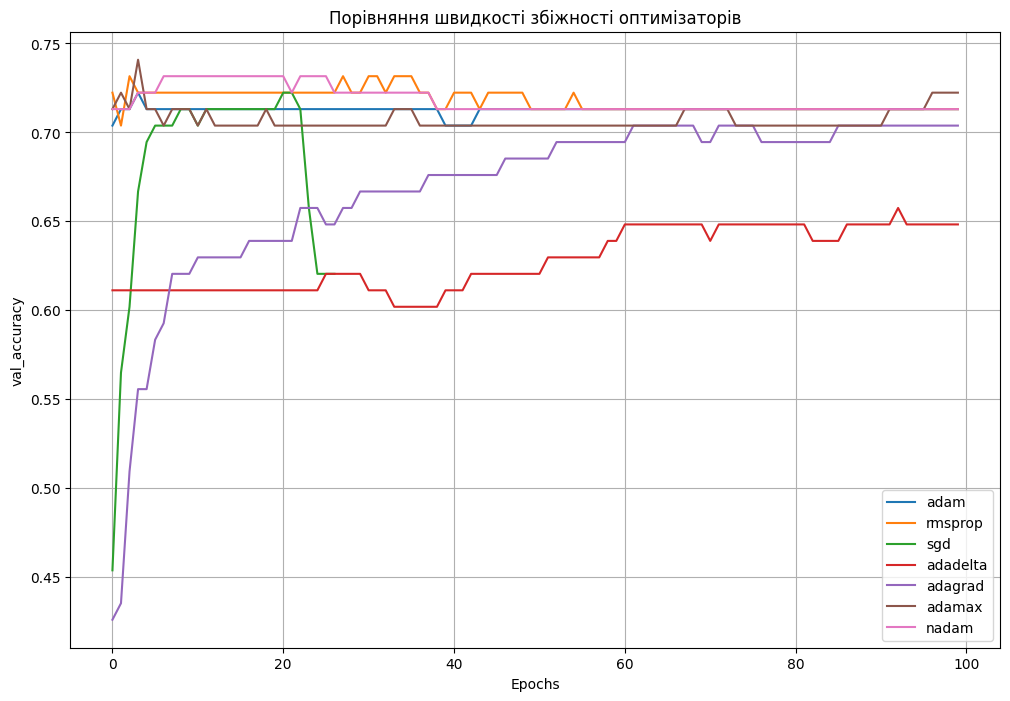

In [19]:
plt.figure(figsize=(12, 8))

# Store validation loss curves and create final loss matrix
val_acc = []
final_loss_matrix = np.zeros((len(optimizers), len(activators)))

for opt_idx, (opt, history) in enumerate(zip(optimizers, histories)):
    plt.plot(history[0]['val_accuracy'], label=opt)

    for act_idx in range(len(activators)):
        loss_curve = history[act_idx]['val_accuracy']
        val_acc.append(loss_curve)
        # Store final loss value
        final_loss_matrix[opt_idx, act_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності оптимізаторів')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.legend()
plt.grid(True)
plt.show()

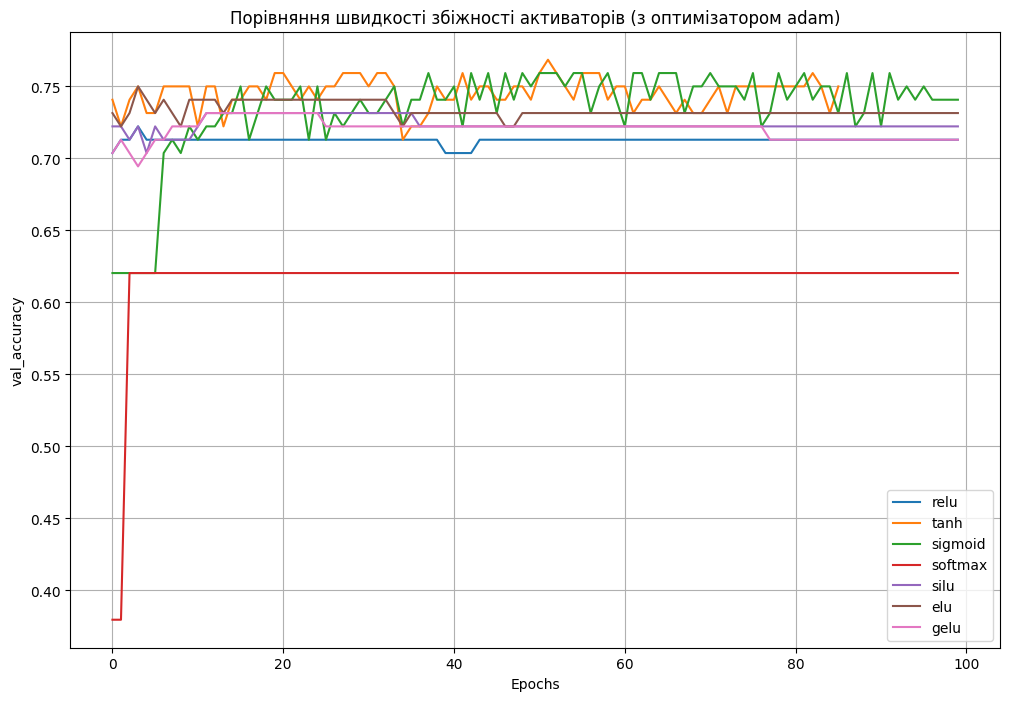

In [20]:
plt.figure(figsize=(12, 8))

# Store validation loss curves and create final loss matrix
val_acc = []
final_loss_matrix = np.zeros((len(activators), len(optimizers)))

for act_idx, act in enumerate(activators):
    # Для кожного активатора беремо першу модель (з оптимізатором 'adam')
    history_for_act = histories[0][act_idx]  # histories[0] - це для 'adam' оптимізатора
    plt.plot(history_for_act['val_accuracy'], label=act)

    for opt_idx in range(len(optimizers)):
        loss_curve = histories[opt_idx][act_idx]['val_accuracy']
        val_acc.append(loss_curve)
        # Store final loss value
        final_loss_matrix[act_idx, opt_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності активаторів (з оптимізатором adam)')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.legend()
plt.grid(True)
plt.show()

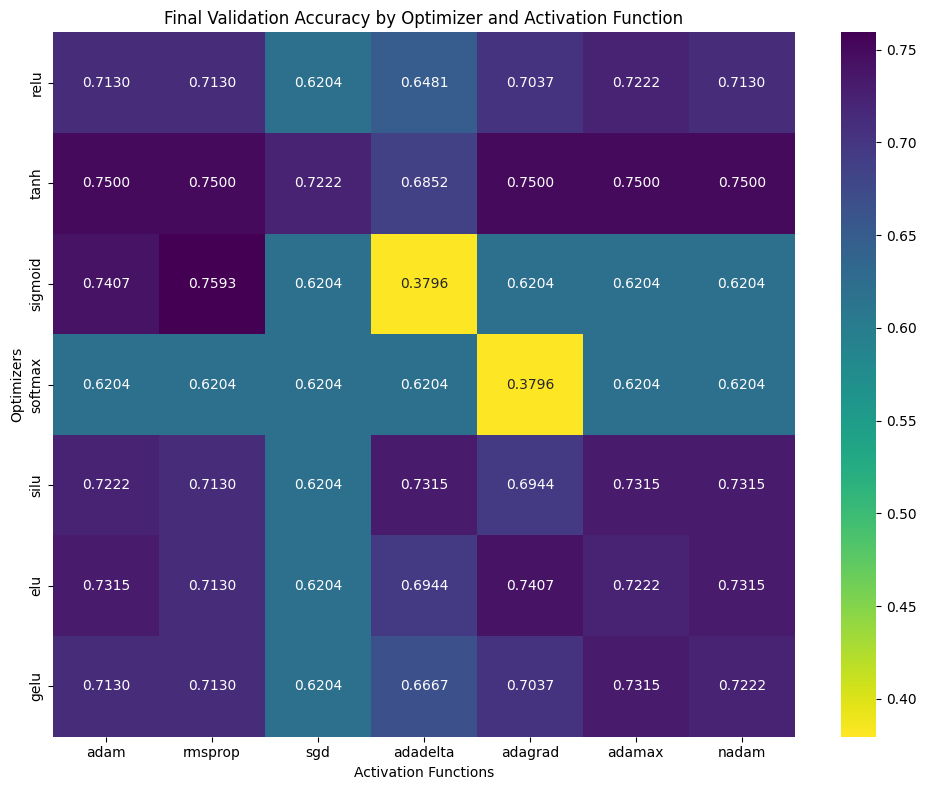

In [21]:
# Plot heatmap of final loss values
plt.figure(figsize=(10, 8))
sns.heatmap(final_loss_matrix,
            xticklabels=optimizers,
            yticklabels=activators,
            annot=True,
            fmt='.4f',
            cmap='viridis_r')
plt.title('Final Validation Accuracy by Optimizer and Activation Function')
plt.xlabel('Activation Functions')
plt.ylabel('Optimizers')
plt.tight_layout()
plt.show()

In [23]:
best_act_idx, best_opt_idx = np.unravel_index(np.argmin(final_loss_matrix), final_loss_matrix.shape)
print(f"Best combination: Activator = {activators[best_act_idx]}, Optimizer = {optimizers[best_opt_idx]}")
print(f"Most final val_accuracy: {final_loss_matrix[best_act_idx, best_opt_idx]:.4f}")

print("\nSorted combinations by val_accuracy:")
combinations = []
for act_idx, act in enumerate(activators):
    for opt_idx, opt in enumerate(optimizers):
        combinations.append((act, opt, final_loss_matrix[act_idx, opt_idx]))

combinations.sort(key=lambda x: x[2], reverse=True)
for act, opt, loss in combinations[:10]:  # Топ-10
    print(f"{act:8} + {opt:10}: {loss:.4f}")

Найкраща комбінація: Активатор = sigmoid, Оптимізатор = adadelta
Найменше фінальне val_loss: 0.3796

Всі комбінації відсортовані за val_accuracy:
sigmoid  + rmsprop   : 0.7593
tanh     + adam      : 0.7500
tanh     + rmsprop   : 0.7500
tanh     + adagrad   : 0.7500
tanh     + adamax    : 0.7500
tanh     + nadam     : 0.7500
sigmoid  + adam      : 0.7407
elu      + adagrad   : 0.7407
silu     + adadelta  : 0.7315
silu     + adamax    : 0.7315


In [59]:
layers = [2, 3, 4, 5, 6]
neurons = [6, 7, 9, 10, 16, 32, 64, 128, 256, 512]
models_diff_lay_neur = []

for l in layers :
    models = []
    for n in neurons :
        model = build_model(X_train, neurons=n, layers=l)
        models.append(model)
    models_diff_lay_neur.append(models)

metrics_diff_lay_neur = []

for layer_models in models_diff_lay_neur:
    layer_metrics = []
    for model in layer_models:
        early_stopping_monitor = EarlyStopping(patience=3)
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        test_y_predictions = model.predict(X_test, verbose=0)
        new_metrics = get_metrics(y_test, test_y_predictions)
        layer_metrics.append(new_metrics)
    metrics_diff_lay_neur.append(layer_metrics)


# Створюємо DataFrame
df = pd.DataFrame(metrics_diff_lay_neur,
                  index=[f'{l} layers' for l in layers],
                  columns=[f'{n} neurons.' for n in neurons])

# Округлюємо до 3 знаків
df = df.round(3)
print(df)

C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


                                                 6 neurons.  \
2 layers  [0.6753246753246753, 0.5280898876404494, 0.854...   
3 layers  [0.6883116883116883, 0.5443037974683544, 0.781...   
4 layers  [0.35714285714285715, 0.35714285714285715, 1.0...   
5 layers  [0.6363636363636364, 0.4953271028037383, 0.963...   
6 layers                [0.7142857142857143, 0.6, 0.6, 0.6]   

                                                 7 neurons.  \
2 layers  [0.7207792207792207, 0.6111111111111112, 0.6, ...   
3 layers  [0.6688311688311688, 0.5222222222222223, 0.854...   
4 layers  [0.38961038961038963, 0.3673469387755102, 0.98...   
5 layers  [0.6428571428571429, 0.5, 0.9272727272727272, ...   
6 layers  [0.6298701298701299, 0.49019607843137253, 0.90...   

                                                 9 neurons.  \
2 layers  [0.6753246753246753, 0.5280898876404494, 0.854...   
3 layers  [0.7402597402597403, 0.6470588235294118, 0.6, ...   
4 layers  [0.7142857142857143, 0.5873015873015873, 0.

So basic option adam+relu is working good for this task, so next experiments will be done using this combination

Check for overfitting

In [11]:
model_new = build_model(X_train, optimizer='adam', activator='relu', layers=2, neurons=10)
early_stopping_monitor = EarlyStopping(patience=3)
model_new.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stopping_monitor],
    verbose=0
)

y_predictions_test = model_new.predict(X_test)
y_predictions_train = model_new.predict(X_train)
test_metrics = get_metrics(y_test, y_predictions_test)
train_metrics = get_metrics(y_train, y_predictions_train)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [12]:
print('train')
print('Precision\tRecall\t\tAccuracy\t\tR2')
print('%.3f' % train_metrics[0], '\t\t%.3f\t' % train_metrics[1], '\t%.3f\t' % train_metrics[2], '\t%.3f\t' % train_metrics[3])

print('test')
print('Precision\tRecall\t\tAccuracy\t\tR2')
print('%.3f' % test_metrics[0], '\t\t%.3f\t' % test_metrics[1], '\t%.3f\t' % test_metrics[2], '\t%.3f\t' % test_metrics[3])

train
Precision	Recall		Accuracy		R2
0.730 		0.575	 	0.872	 	0.693	
test
Precision	Recall		Accuracy		R2
0.701 		0.552	 	0.873	 	0.676	
